## 27 — Citation Network Analysis

**Option B — Who Cites Award Papers?**
- Plot 1: Year distribution of citing papers
- Plot 2: Field distribution
- Plot 3: Connector papers
- Plot 4: Citation lag heatmap

**Option C — Referenced vs. Citing**
- Plot 5: Field comparison (cited vs. citing)
- Plot 6: Publication year KDE
- Plot 7: Source type comparison
- Plot 8: Topic shift heatmap

**Output figures:** `figures/p27_0X_*.png`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import requests
import time
from pathlib import Path
from scipy.stats import gaussian_kde

plt.rcParams.update({
    'figure.dpi'       : 150,
    'figure.facecolor' : 'white',
    'axes.facecolor'   : 'white',
    'axes.edgecolor'   : 'black',
    'axes.linewidth'   : 0.8,
    'axes.grid'        : False,
    'font.family'      : 'Arial',
    'font.size'        : 11,
    'axes.titlesize'   : 13,
    'axes.titleweight' : 'bold',
    'xtick.direction'  : 'out',
    'ytick.direction'  : 'out',
    'legend.frameon'   : True,
    'legend.edgecolor' : '#cccccc',
})

DATA = Path(r'B:\Semester 4 UU\thesis-best-paper-trajectories\data\matched')
FIG  = Path(r'B:\Semester 4 UU\thesis-best-paper-trajectories\figures')
FIG.mkdir(parents=True, exist_ok=True)

citing  = pd.read_csv(DATA / 'citing_papers.csv',  low_memory=False)
c_edges = pd.read_csv(DATA / 'award_to_citing_edges.csv')
cited   = pd.read_csv(DATA / 'cited_papers.csv',   low_memory=False)
r_edges = pd.read_csv(DATA / 'award_to_cited_edges.csv')
awards  = pd.read_csv(DATA / 'huang_matched_openalex.csv')

print(f'citing_papers        : {len(citing):,} rows')
print(f'award_to_citing_edges: {len(c_edges):,} rows')
print(f'cited_papers         : {len(cited):,} rows')
print(f'award_to_cited_edges : {len(r_edges):,} rows')
print(f'award_papers         : {len(awards):,} rows')

citing_papers        : 438,807 rows
award_to_citing_edges: 507,718 rows
cited_papers         : 26,921 rows
award_to_cited_edges : 34,417 rows
award_papers         : 912 rows


---
## Option B — Who Cites Award Papers?
### Plot 1 — Year distribution of citing papers

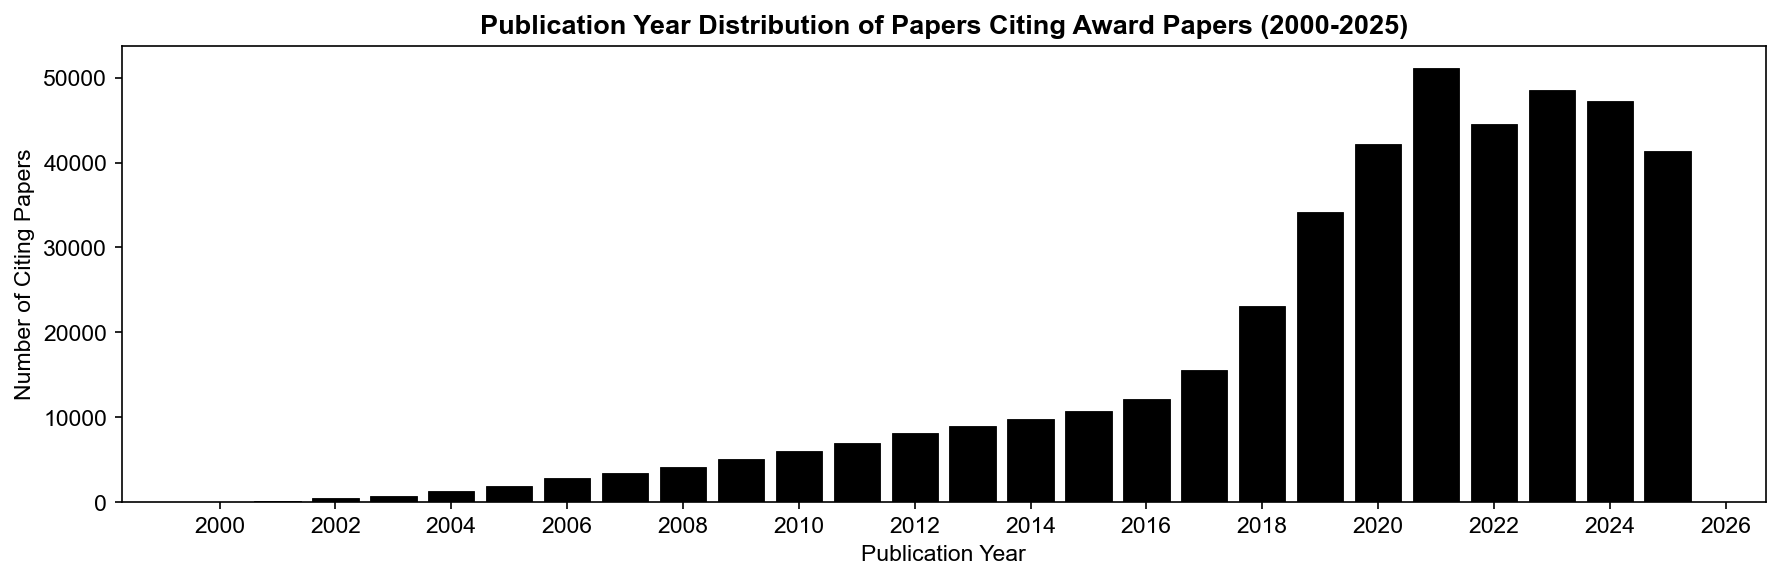

Peak year: 2021 (51,175 papers)


In [2]:
yr = citing['publication_year'].dropna().astype(int)
yr_counts = yr[(yr >= 2000) & (yr <= 2025)].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(yr_counts.index, yr_counts.values, color='black', edgecolor='black', linewidth=0.4, width=0.8)
ax.set_xlabel('Publication Year')
ax.set_ylabel('Number of Citing Papers')
ax.set_title('Publication Year Distribution of Papers Citing Award Papers (2000-2025)')
ax.xaxis.set_major_locator(mticker.MultipleLocator(2))
plt.tight_layout()
plt.savefig(FIG / 'p27_01_citing_year_dist.png', dpi=150)
plt.show()
print(f'Peak year: {yr_counts.idxmax()} ({yr_counts.max():,} papers)')

### Plot 2 — Field distribution of citing papers

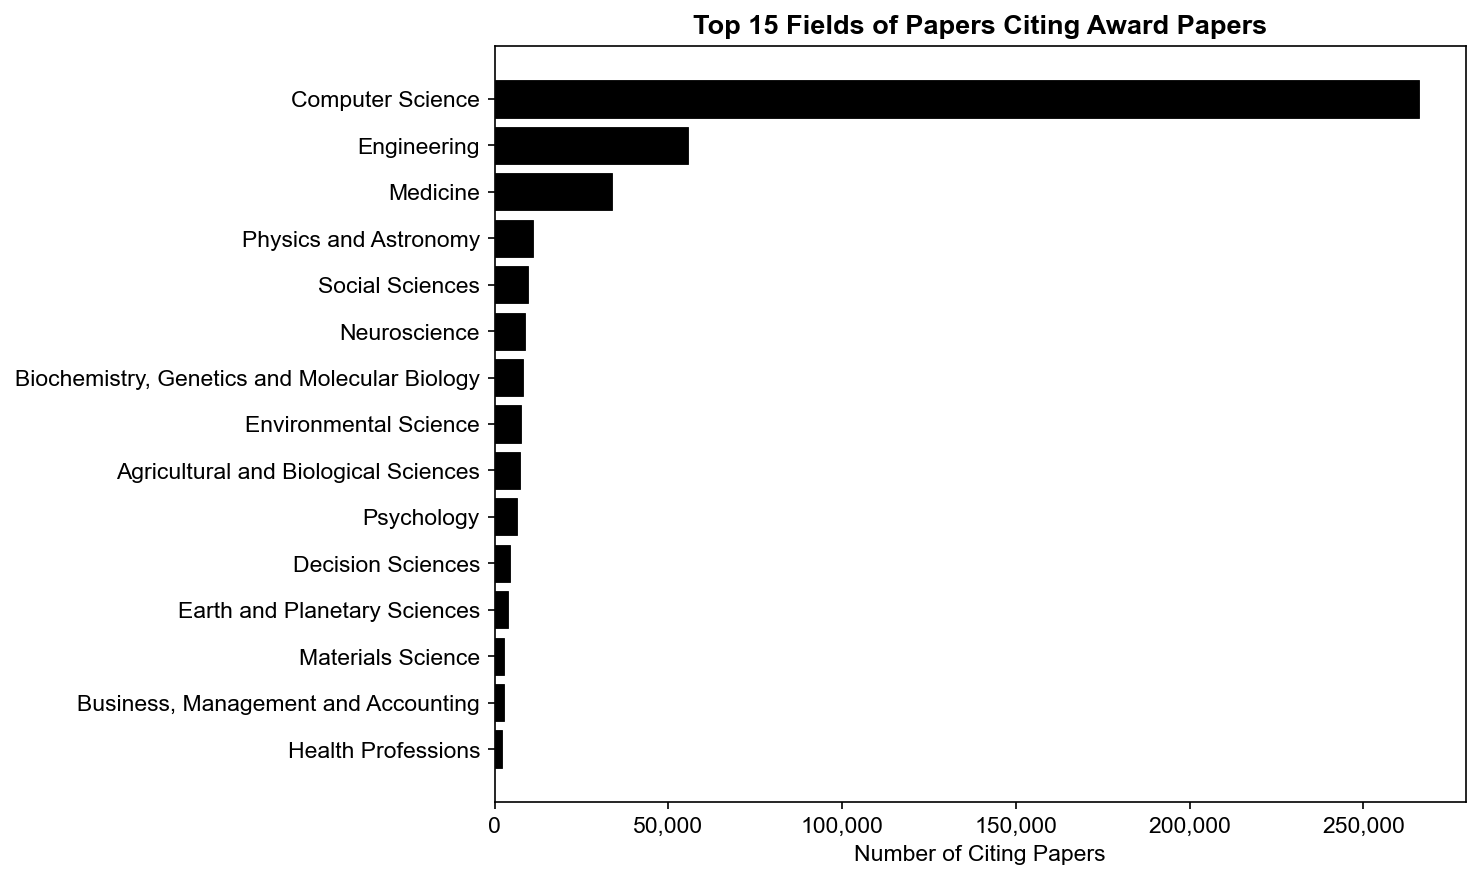

CS share of top-15 fields: 61.8%


In [3]:
field_counts = (
    citing['top_field'].replace('', pd.NA).dropna()
    .value_counts().head(15)
)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(field_counts.index[::-1], field_counts.values[::-1], color='black', edgecolor='black', linewidth=0.4)
ax.set_xlabel('Number of Citing Papers')
ax.set_title('Top 15 Fields of Papers Citing Award Papers')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.savefig(FIG / 'p27_02_citing_field_dist.png', dpi=150)
plt.show()
pct_cs = field_counts.get('Computer Science', 0) / field_counts.sum() * 100
print(f'CS share of top-15 fields: {pct_cs:.1f}%')

### Plot 3 — Connector papers (cite >= 2 award papers)

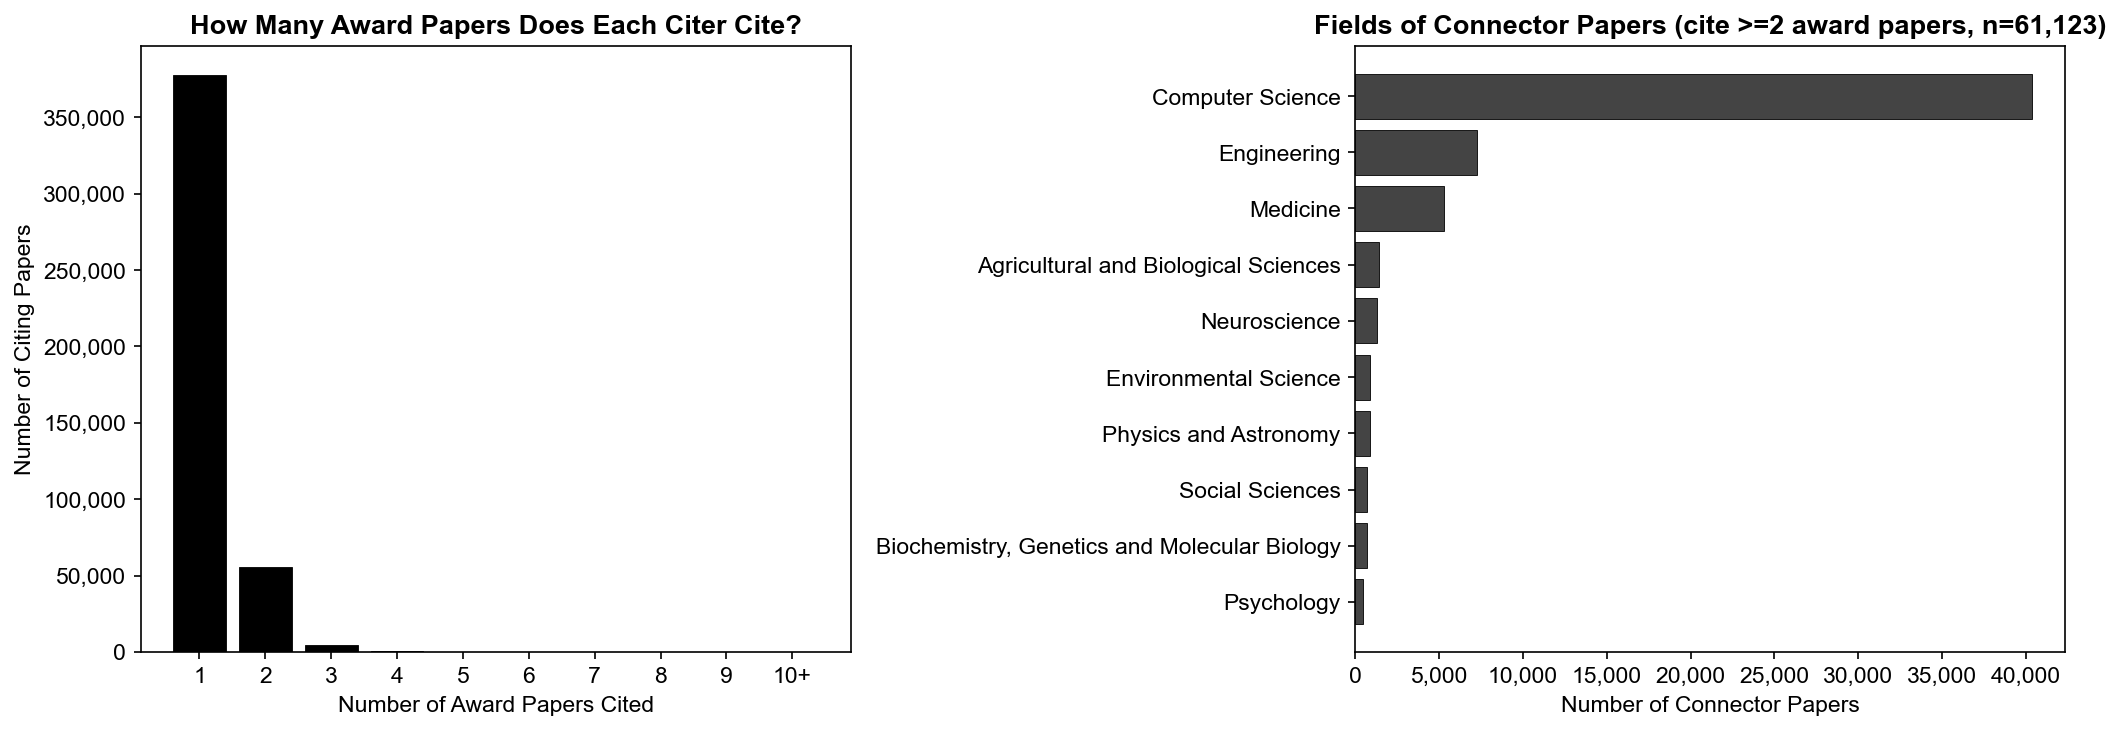

Connector papers (>=2): 61,123  (13.9% of all citers)


In [4]:
citing['cites_n_award_papers'] = pd.to_numeric(citing['cites_n_award_papers'], errors='coerce').fillna(1).astype(int)

n_dist = citing['cites_n_award_papers'].clip(upper=10).value_counts().sort_index()
labels = [str(i) if i < 10 else '10+' for i in n_dist.index]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(labels, n_dist.values, color='black', edgecolor='black', linewidth=0.4)
axes[0].set_xlabel('Number of Award Papers Cited')
axes[0].set_ylabel('Number of Citing Papers')
axes[0].set_title('How Many Award Papers Does Each Citer Cite?')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

connectors  = citing[citing['cites_n_award_papers'] >= 2]
conn_fields = connectors['top_field'].replace('', pd.NA).dropna().value_counts().head(10)

axes[1].barh(conn_fields.index[::-1], conn_fields.values[::-1], color='#444', edgecolor='black', linewidth=0.4)
axes[1].set_xlabel('Number of Connector Papers')
axes[1].set_title(f'Fields of Connector Papers (cite >=2 award papers, n={len(connectors):,})')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.savefig(FIG / 'p27_03_connector_papers.png', dpi=150)
plt.show()
print(f'Connector papers (>=2): {len(connectors):,}  ({len(connectors)/len(citing)*100:.1f}% of all citers)')

### Plot 4 — Citation lag heatmap (award cohort year -> citing year)

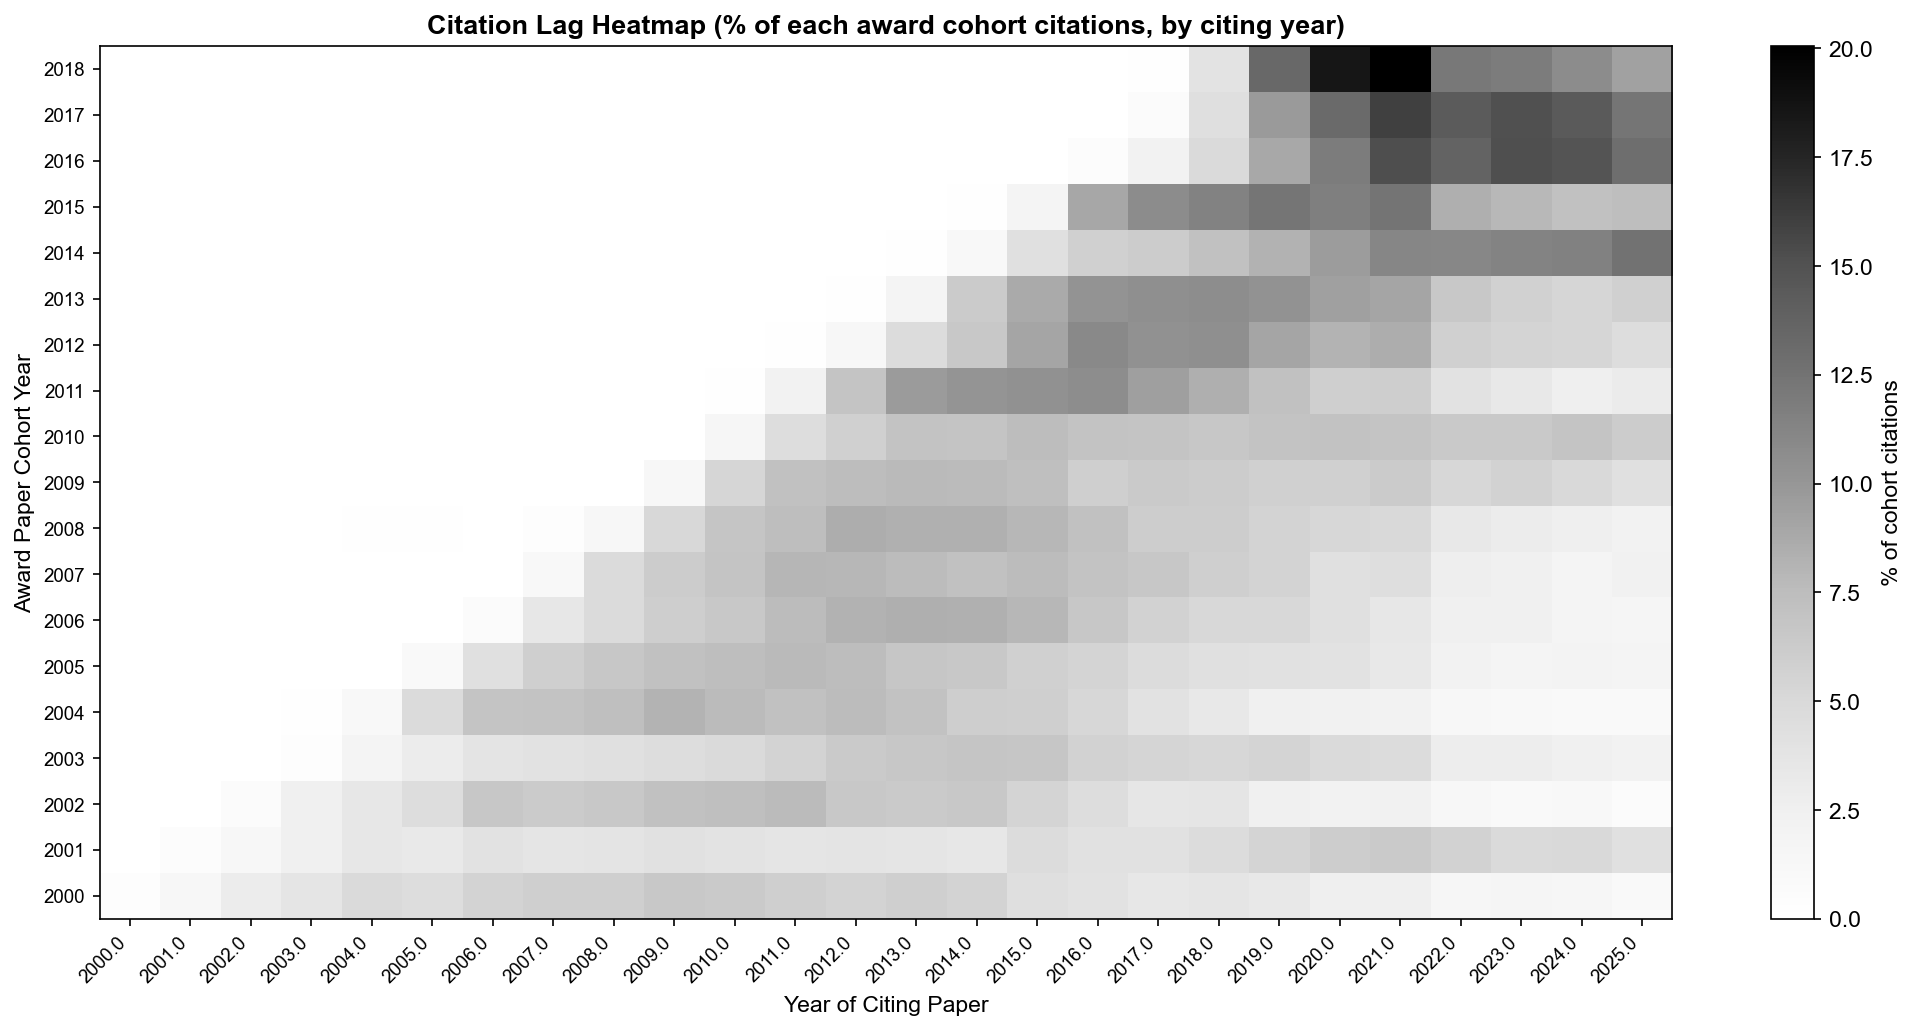

In [5]:
c_edges['award_year'] = pd.to_numeric(c_edges['award_year'], errors='coerce')
cite_yr = citing[['openalex_id', 'publication_year']].copy()
cite_yr.columns = ['citing_paper_id', 'citing_year']

lag_df = c_edges.merge(cite_yr, on='citing_paper_id', how='left')
lag_df['citing_year'] = pd.to_numeric(lag_df['citing_year'], errors='coerce')
lag_df = lag_df[lag_df['award_year'].between(2000, 2018) & lag_df['citing_year'].between(2000, 2025)]

pivot = lag_df.groupby(['award_year', 'citing_year']).size().unstack(fill_value=0)
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(14, 7))
im = ax.imshow(pivot_pct.values, aspect='auto', cmap='Greys', origin='lower', vmin=0, vmax=pivot_pct.values.max())
ax.set_xticks(range(len(pivot_pct.columns)))
ax.set_xticklabels(pivot_pct.columns, rotation=45, ha='right', fontsize=9)
ax.set_yticks(range(len(pivot_pct.index)))
ax.set_yticklabels(pivot_pct.index, fontsize=9)
ax.set_xlabel('Year of Citing Paper')
ax.set_ylabel('Award Paper Cohort Year')
ax.set_title('Citation Lag Heatmap (% of each award cohort citations, by citing year)')
plt.colorbar(im, ax=ax, label='% of cohort citations')
plt.tight_layout()
plt.savefig(FIG / 'p27_04_citation_lag_heatmap.png', dpi=150)
plt.show()

Y-axis = the year the award paper was published (cohort year, 2000–2018)

X-axis = the calendar year in which citing papers were published (2000–2025)

---
## Option C — Referenced (backward) vs. Citing (forward)
### Plot 5 — Field distribution: cited vs. citing

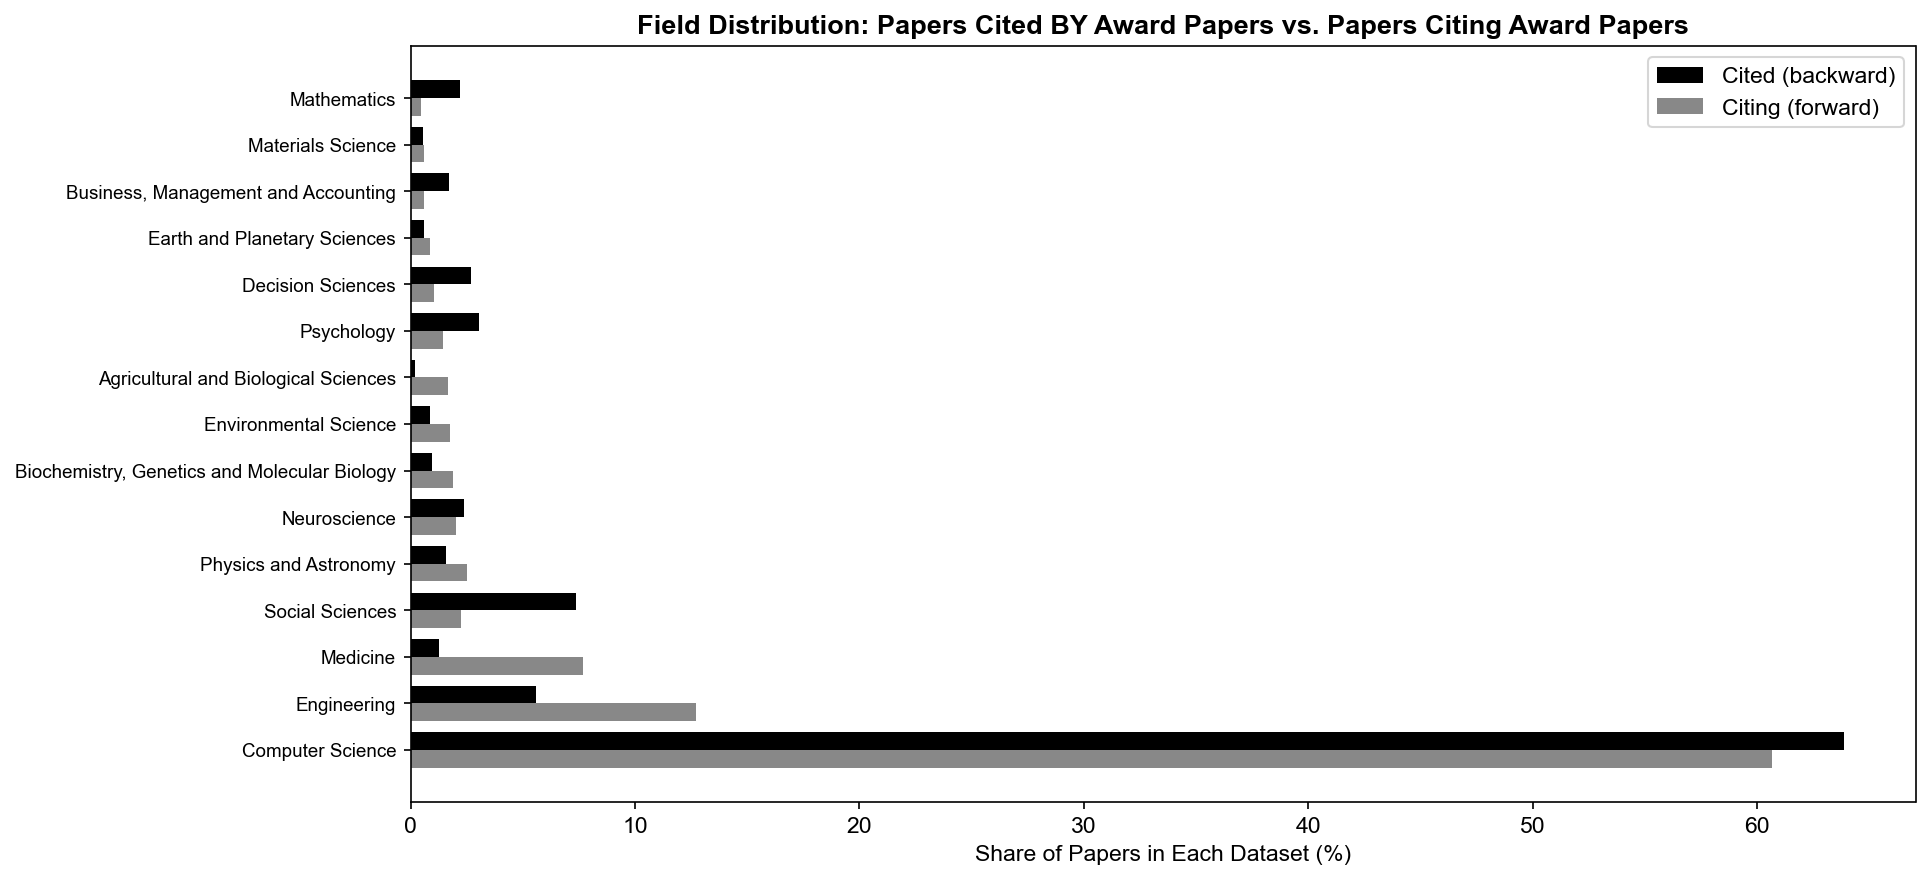

In [6]:
ref_fields = cited['top_field'].replace('', pd.NA).dropna().value_counts()
cit_fields = citing['top_field'].replace('', pd.NA).dropna().value_counts()

top_fields = (
    pd.concat([ref_fields, cit_fields]).groupby(level=0).sum()
    .sort_values(ascending=False).head(15).index.tolist()
)
ref_pct = ref_fields.reindex(top_fields, fill_value=0) / ref_fields.sum() * 100
cit_pct = cit_fields.reindex(top_fields, fill_value=0) / cit_fields.sum() * 100

x, w = np.arange(len(top_fields)), 0.38
fig, ax = plt.subplots(figsize=(13, 6))
ax.barh(x + w/2, ref_pct.values, height=w, color='black', label='Cited (backward)', hatch='///')
ax.barh(x - w/2, cit_pct.values, height=w, color='#888',  label='Citing (forward)')
ax.set_yticks(x)
ax.set_yticklabels(top_fields, fontsize=9)
ax.set_xlabel('Share of Papers in Each Dataset (%)')
ax.set_title('Field Distribution: Papers Cited BY Award Papers vs. Papers Citing Award Papers')
ax.legend()
plt.tight_layout()
plt.savefig(FIG / 'p27_05_field_cited_vs_citing.png', dpi=150)
plt.show()

### Plot 6 — Publication year KDE: backward vs. forward

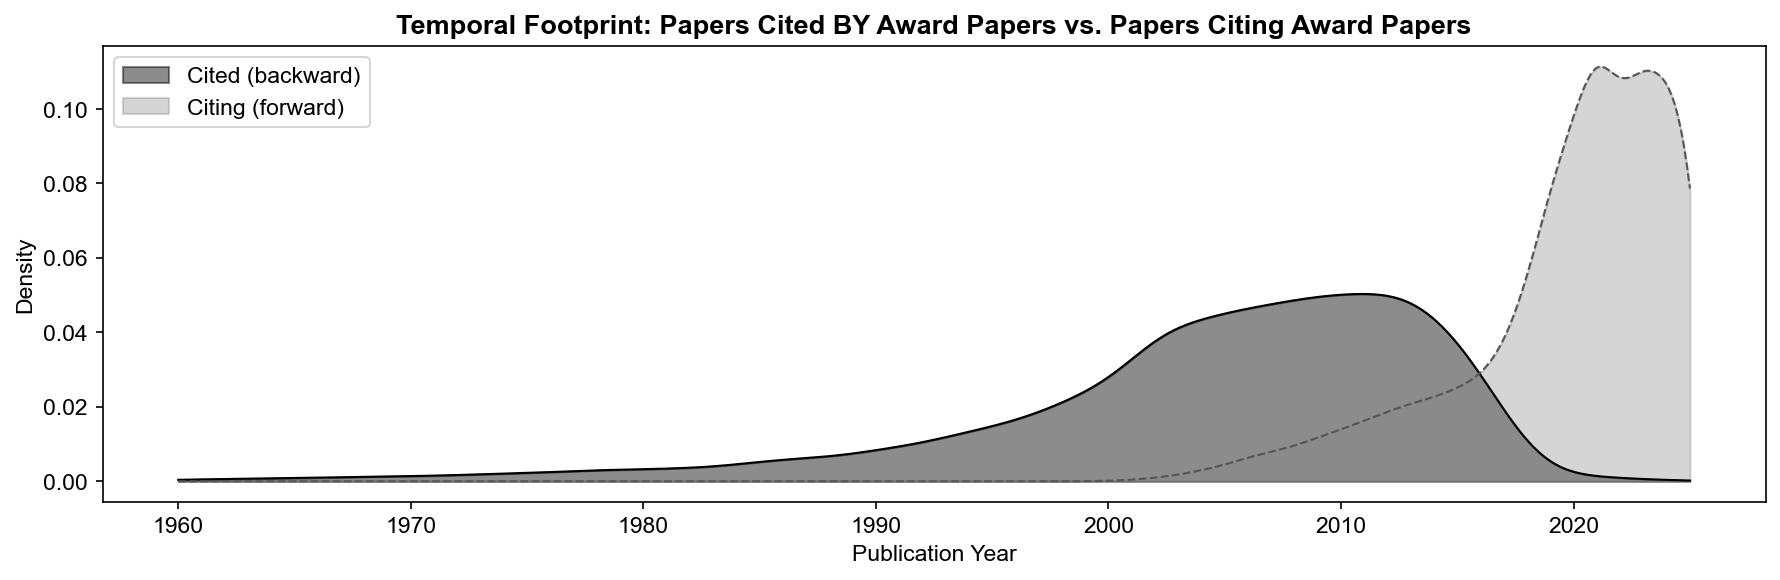

In [7]:
ref_yr = cited['publication_year'].dropna().astype(float)
cit_yr = citing['publication_year'].dropna().astype(float)
ref_yr = ref_yr[(ref_yr >= 1960) & (ref_yr <= 2025)]
cit_yr = cit_yr[(cit_yr >= 1960) & (cit_yr <= 2025)]

xs = np.linspace(1960, 2025, 500)
kde_ref = gaussian_kde(ref_yr, bw_method=0.15)
kde_cit = gaussian_kde(cit_yr, bw_method=0.15)

fig, ax = plt.subplots(figsize=(12, 4))
ax.fill_between(xs, kde_ref(xs), alpha=0.45, color='black', label='Cited (backward)')
ax.fill_between(xs, kde_cit(xs), alpha=0.35, color='#888',  label='Citing (forward)')
ax.plot(xs, kde_ref(xs), color='black', linewidth=1)
ax.plot(xs, kde_cit(xs), color='#555',  linewidth=1, linestyle='--')
ax.set_xlabel('Publication Year')
ax.set_ylabel('Density')
ax.set_title('Temporal Footprint: Papers Cited BY Award Papers vs. Papers Citing Award Papers')
ax.legend()
plt.tight_layout()
plt.savefig(FIG / 'p27_06_year_kde_cited_vs_citing.png', dpi=150)
plt.show()

Dark grey (Cited / backward) = distribution of publication years of papers referenced by award papers — i.e., how old the literature is that award papers cite. The bulk sits around 1995–2015, peaking near 2007, meaning award papers mostly cite work that is ~5–20 years old at time of writing.

Light grey (Citing / forward) = distribution of publication years of papers that later cite award papers. This is heavily skewed toward 2018–2025, reflecting that most forward citations come from very recent work.



### Plot 7 — Source type: cited vs. citing

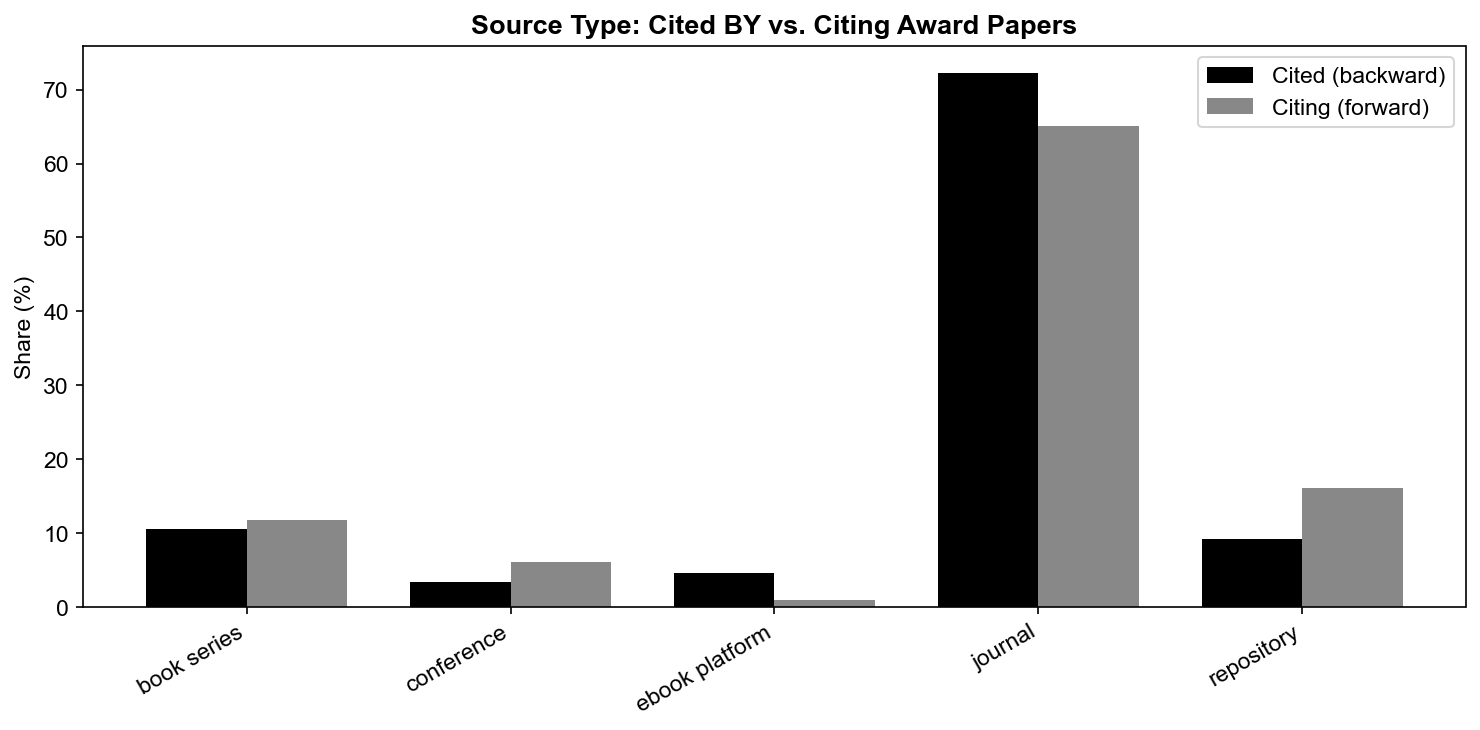

In [8]:
ref_src = cited['source_type'].replace('', pd.NA).dropna().value_counts(normalize=True) * 100
cit_src = citing['source_type'].replace('', pd.NA).dropna().value_counts(normalize=True) * 100
all_types = sorted(set(ref_src.index) | set(cit_src.index))
ref_src = ref_src.reindex(all_types, fill_value=0)
cit_src = cit_src.reindex(all_types, fill_value=0)

x, w = np.arange(len(all_types)), 0.38
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - w/2, ref_src.values, width=w, color='black', label='Cited (backward)', hatch='///')
ax.bar(x + w/2, cit_src.values, width=w, color='#888',  label='Citing (forward)')
ax.set_xticks(x)
ax.set_xticklabels(all_types, rotation=30, ha='right')
ax.set_ylabel('Share (%)')
ax.set_title('Source Type: Cited BY vs. Citing Award Papers')
ax.legend()
plt.tight_layout()
plt.savefig(FIG / 'p27_07_source_type_cited_vs_citing.png', dpi=150)
plt.show()

### Plot 8 — Topic shift heatmap

#### Step 8a — Fetch top_field for all award papers from OpenAlex
huang_matched_openalex.csv has no top_field and the join against cited_papers.csv only covers ~27%.
We batch-fetch directly from OpenAlex (~9 requests) and cache to award_papers_field.csv.

In [9]:
MAILTO            = 'shaheryar.4822@student.uu.se'
API_KEY           = 'A08hCjeUoeVKA9toVsfCpF'
BASE_URL          = 'https://api.openalex.org'
AWARD_FIELD_CACHE = DATA / 'award_papers_field.csv'

def api_get(url, params=None):
    p = {'mailto': MAILTO, 'api_key': API_KEY}
    if params:
        p.update(params)
    for _ in range(3):
        try:
            r = requests.get(url, params=p, timeout=15)
            if r.status_code == 200:
                return r.json()
            if r.status_code == 429:
                time.sleep(5)
        except requests.RequestException:
            time.sleep(2)
    return None

if AWARD_FIELD_CACHE.exists():
    award_field_df = pd.read_csv(AWARD_FIELD_CACHE)
    print(f'Loaded from cache: {len(award_field_df)} rows')
else:
    award_ids = c_edges['award_paper_id'].dropna().unique().tolist()
    print(f'Fetching top_field for {len(award_ids)} award papers...')
    records = []
    BATCH   = 100
    batches = [award_ids[i:i+BATCH] for i in range(0, len(award_ids), BATCH)]
    for b_idx, batch in enumerate(batches, 1):
        ids_str = '|'.join([i.split('/')[-1] for i in batch])
        resp = api_get(f'{BASE_URL}/works', params={
            'filter'  : f'openalex_id:{ids_str}',
            'per-page': 100,
            'select'  : 'id,topics'
        })
        time.sleep(0.15)
        if resp:
            for w in resp.get('results', []):
                topics    = w.get('topics', [])
                top_field = topics[0].get('field', {}).get('display_name', '') if topics else ''
                records.append({'award_paper_id': w['id'], 'award_field': top_field})
        print(f'  batch {b_idx}/{len(batches)} done')
    award_field_df = pd.DataFrame(records)
    award_field_df['award_field'] = award_field_df['award_field'].replace('', pd.NA).fillna('Computer Science')
    award_field_df.to_csv(AWARD_FIELD_CACHE, index=False)
    print(f'Saved {len(award_field_df)} rows to {AWARD_FIELD_CACHE.name}')

print(award_field_df['award_field'].value_counts().head(10))

Loaded from cache: 879 rows
award_field
Computer Science                       707
Engineering                             44
Social Sciences                         29
Decision Sciences                       21
Neuroscience                            16
Physics and Astronomy                   13
Psychology                               9
Mathematics                              7
Business, Management and Accounting      6
Arts and Humanities                      6
Name: count, dtype: int64


#### Step 8b — Build and plot the topic shift heatmap

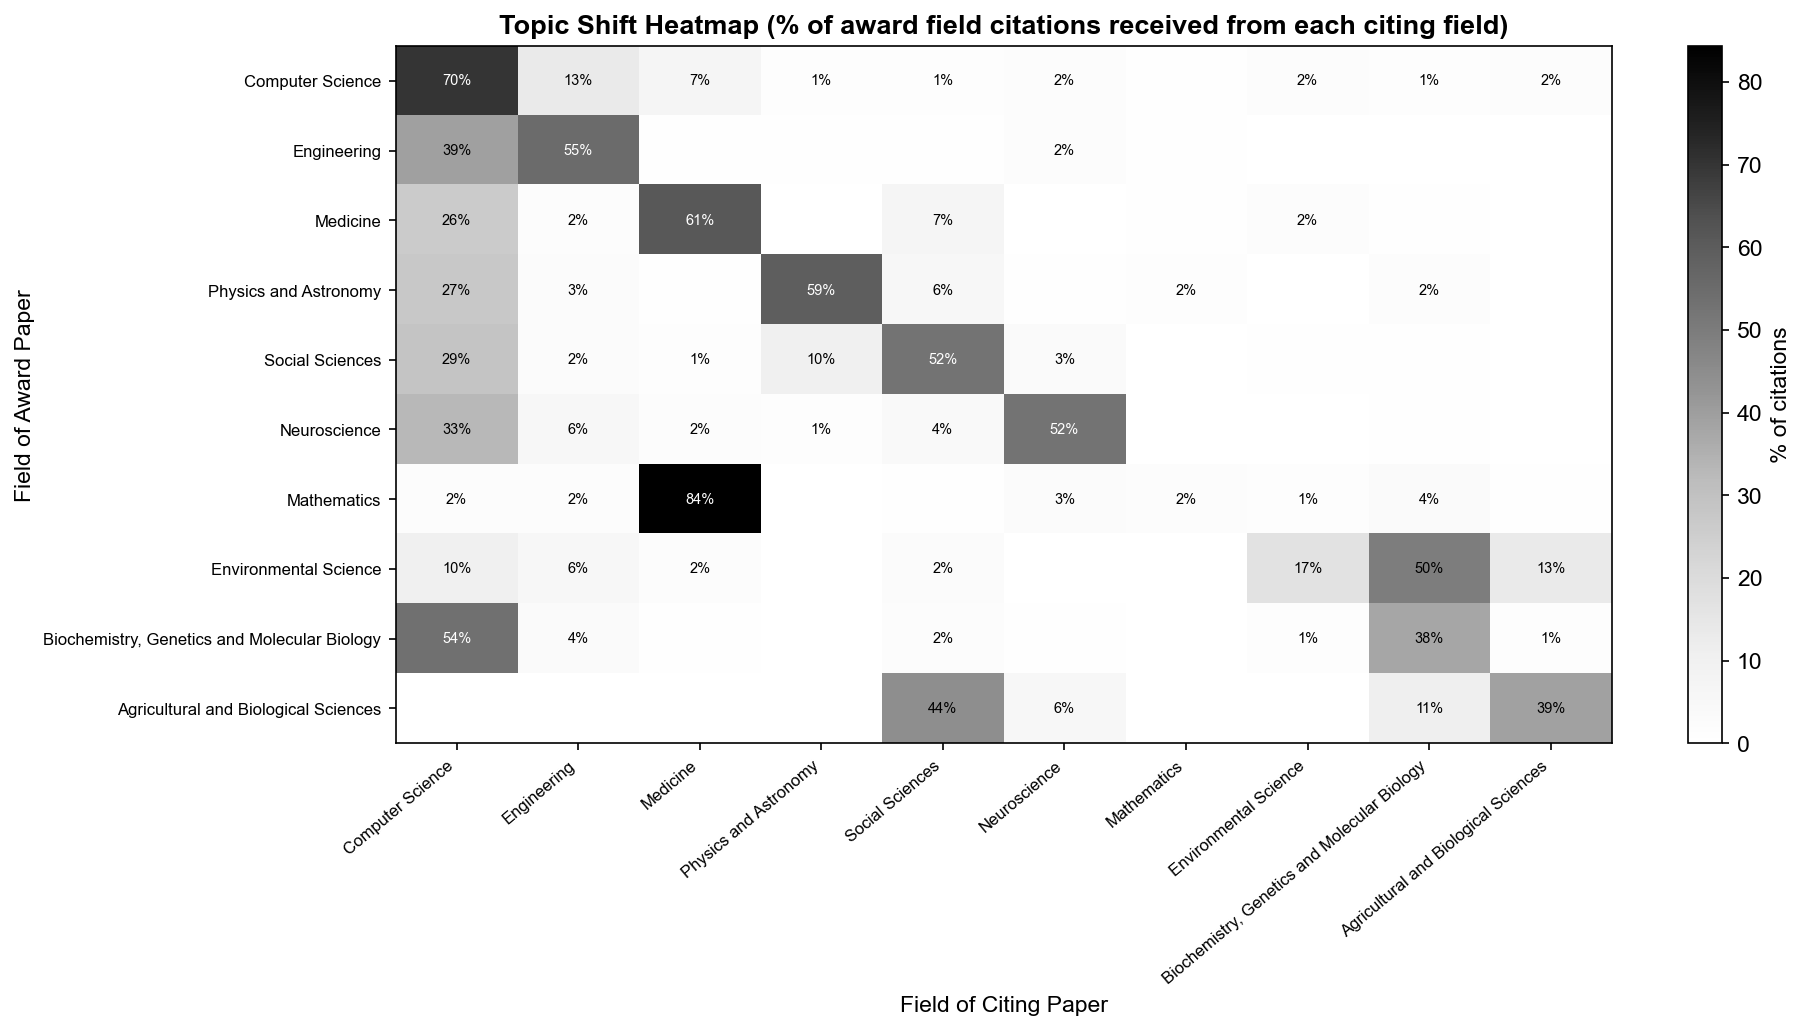

Done - all 8 figures saved to figures/


In [11]:
citing_field = (
    citing[['openalex_id', 'top_field']]
    .replace('', pd.NA).dropna(subset=['top_field'])
    .rename(columns={'openalex_id': 'citing_paper_id', 'top_field': 'citing_field'})
)

shift = (
    c_edges
    .merge(award_field_df, on='award_paper_id', how='inner')
    .merge(citing_field,  on='citing_paper_id', how='inner')
)

top_fields = (
    pd.concat([shift['award_field'], shift['citing_field']])
    .value_counts().head(10).index.tolist()
)
top_award_fields  = top_fields
top_citing_fields = top_fields

# Then reindex with the SAME list for both axes
pivot_shift = (
    shift_sub.groupby(['award_field', 'citing_field']).size()
    .unstack(fill_value=0)
    .reindex(index=top_fields, columns=top_fields, fill_value=0)  # <-- same list both times
)


shift_sub = shift[
    shift['award_field'].isin(top_award_fields) &
    shift['citing_field'].isin(top_citing_fields)
]

pivot_shift = (
    shift_sub.groupby(['award_field', 'citing_field']).size()
    .unstack(fill_value=0)
    .reindex(index=top_award_fields, columns=top_citing_fields, fill_value=0)
)
pivot_pct = pivot_shift.div(pivot_shift.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(13, 7))
im = ax.imshow(pivot_pct.values, aspect='auto', cmap='Greys', vmin=0)
ax.set_xticks(range(len(pivot_pct.columns)))
ax.set_xticklabels(pivot_pct.columns, rotation=40, ha='right', fontsize=8)
ax.set_yticks(range(len(pivot_pct.index)))
ax.set_yticklabels(pivot_pct.index, fontsize=8)
ax.set_xlabel('Field of Citing Paper')
ax.set_ylabel('Field of Award Paper')
ax.set_title('Topic Shift Heatmap (% of award field citations received from each citing field)')
plt.colorbar(im, ax=ax, label='% of citations')

for i in range(len(pivot_pct.index)):
    for j in range(len(pivot_pct.columns)):
        v = pivot_pct.values[i, j]
        if v > 1:
            color = 'white' if v > pivot_pct.values.max() * 0.6 else 'black'
            ax.text(j, i, f'{v:.0f}%', ha='center', va='center', fontsize=7, color=color)

plt.tight_layout()
plt.savefig(FIG / 'p27_08_topic_shift_heatmap.png', dpi=150)
plt.show()
print('Done - all 8 figures saved to figures/')

Y-axis = the field of the award paper (who got cited)

X-axis = the field of the citing paper (who cited them)

Cell value = % of that award field's total citations coming from that citing field

Diagonal = self-citation within field. Mathematics is the most self-contained (85%), meaning almost all citations to Math award papers come from other Math papers. Computer Science is also fairly self-contained at 69%.

Off-diagonal = cross-field impact. Engineering award papers get 55% of their citations from CS papers — meaning CS heavily builds on Engineering work. Physics & Astronomy award papers get 60% of citations from Physics itself, but also 28% from CS.

CS as a universal importer. The entire leftmost column is non-zero across every field, confirming that CS citing papers reach into virtually every other discipline.